In [446]:
import pandas as pd
import numpy as np

In [447]:
# Load the dataset
df = pd.read_csv("../data/raw/ecommerce_sales.csv")

In [448]:
# See the first 5 rows
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Product_Cost,Discount,Payment_Method,Region,City,Order_Status,Shipping_Cost
0,ORD10001,2025-12-15,CUST189,Backpack,Accessories,3,1800,1100,10.0,Cash on Delivery,West,Mumbai,Returned,121
1,ORD10002,2025-08-03,CUST100,Coffee Maker,Home Appliances,3,4500,3000,10.0,Debit Card,North,Jaipur,Cancelled,137
2,ORD10003,2025-12-10,CUST277,Office Chair,Furniture,4,8500,6000,5.0,UPI,North,Lucknow,Delivered,241
3,ORD10004,2025-09-10,CUST059,Coffee Maker,Home Appliances,4,4500,3000,0.0,Credit Card,West,Ahmedabad,Delivered,98
4,ORD10005,2025-12-30,CUST131,Bookshelf,Furniture,3,7000,4800,15.0,Cash on Delivery,North,Jaipur,Delivered,369


In [449]:
# Check the number of rows and columns
df.shape

(1001, 14)

In [450]:
# Inspect column names
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category',
       'Quantity', 'Unit_Price', 'Product_Cost', 'Discount', 'Payment_Method',
       'Region', 'City', 'Order_Status', 'Shipping_Cost'],
      dtype='str')

In [451]:
# Check data types
df.dtypes

Order_ID              str
Order_Date            str
Customer_ID           str
Product               str
Category              str
Quantity            int64
Unit_Price          int64
Product_Cost        int64
Discount          float64
Payment_Method        str
Region                str
City                  str
Order_Status          str
Shipping_Cost       int64
dtype: object

In [452]:
# Get basic statistics
df.describe()

,Quantity,Unit_Price,Product_Cost,Discount,Shipping_Cost
count,1001.000000,1001.000000,1001.000000,1000.00000,1001.000000
mean,2.487512,11013.686314,8043.356643,10.01000,277.490509
std,1.106388,15055.864057,11613.724567,6.95329,135.000934
min,1.000000,900.000000,500.000000,0.00000,50.000000
25%,2.000000,3500.000000,2200.000000,5.00000,155.000000
50%,2.000000,5000.000000,3300.000000,10.00000,275.000000
75%,3.000000,12000.000000,8500.000000,15.00000,400.000000
max,4.000000,55000.000000,42000.000000,20.00000,500.000000


In [453]:
# Check missing values
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Product           0
Category          0
Quantity          0
Unit_Price        0
Product_Cost      0
Discount          1
Payment_Method    1
Region            0
City              1
Order_Status      0
Shipping_Cost     0
dtype: int64

In [454]:
# Check duplicate rows
df.duplicated().sum()

np.int64(1)

In [455]:
# Get a complete dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1001 non-null   str    
 1   Order_Date      1001 non-null   str    
 2   Customer_ID     1001 non-null   str    
 3   Product         1001 non-null   str    
 4   Category        1001 non-null   str    
 5   Quantity        1001 non-null   int64  
 6   Unit_Price      1001 non-null   int64  
 7   Product_Cost    1001 non-null   int64  
 8   Discount        1000 non-null   float64
 9   Payment_Method  1000 non-null   str    
 10  Region          1001 non-null   str    
 11  City            1000 non-null   str    
 12  Order_Status    1001 non-null   str    
 13  Shipping_Cost   1001 non-null   int64  
dtypes: float64(1), int64(4), str(9)
memory usage: 182.5 KB


In [456]:
# Data Cleaning
cleaned_df = df.copy()

In [457]:
# Convert Order_Date
cleaned_df["Order_Date"] = pd.to_datetime(
    cleaned_df["Order_Date"],
    errors="coerce"
)

In [458]:
cleaned_df["Order_Date"].dtype

dtype('<M8[us]')

In [459]:
# Handle missing Discount
cleaned_df["Discount"].isnull().sum()

np.int64(1)

In [460]:
cleaned_df["Discount"] = cleaned_df["Discount"].fillna(0)

In [461]:
cleaned_df["Discount"].isnull().sum()

np.int64(0)

In [462]:
# Handle missing Payment_Method
cleaned_df["Payment_Method"] = cleaned_df["Payment_Method"].fillna(
    "Unknown"
)

In [463]:
cleaned_df["Payment_Method"].isnull().sum()

np.int64(0)

In [464]:
# Handle missing City
cleaned_df["City"] = cleaned_df["City"].fillna("Unknown")

In [465]:
cleaned_df["City"].isnull().sum()

np.int64(0)

In [466]:
# Remove duplicate transactions
cleaned_df.duplicated().sum()

np.int64(1)

In [467]:
cleaned_df = cleaned_df.drop_duplicates()

In [468]:
cleaned_df.shape

(1000, 14)

In [469]:
# Check all missing values
cleaned_df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Product           0
Category          0
Quantity          0
Unit_Price        0
Product_Cost      0
Discount          0
Payment_Method    0
Region            0
City              0
Order_Status      0
Shipping_Cost     0
dtype: int64

In [470]:
# Create business calculation columns
# Gross Sales
#Quantity × Unit Price
cleaned_df["Gross_Sales"] = (
    cleaned_df["Quantity"] * cleaned_df["Unit_Price"]
)
# Discount Amount
# Gross Sales × Discount / 100
cleaned_df["Discount_Amount"] = (
    cleaned_df["Gross_Sales"] * cleaned_df["Discount"] / 100
)
# Net Sales
#Gross Sales - Discount Amount
cleaned_df["Net_Sales"] = (
    cleaned_df["Gross_Sales"] - cleaned_df["Discount_Amount"]
)
cleaned_df["Total_Product_Cost"] = (
    cleaned_df["Quantity"] * cleaned_df["Product_Cost"]
)
cleaned_df["Profit"] = (
    cleaned_df["Net_Sales"]
    - cleaned_df["Total_Product_Cost"]
    - cleaned_df["Shipping_Cost"]
)
cleaned_df["Profit_Margin"] = (
    cleaned_df["Profit"] / cleaned_df["Net_Sales"] * 100
)
# Total Revenue after shipping cost
cleaned_df["Contribution_After_Shipping"] = (
    cleaned_df["Net_Sales"] - cleaned_df["Shipping_Cost"]
)

In [471]:
# Create time-based columns
cleaned_df["Year"] = cleaned_df["Order_Date"].dt.year
cleaned_df["Month"] = cleaned_df["Order_Date"].dt.month
cleaned_df["Month_Name"] = cleaned_df["Order_Date"].dt.month_name()
cleaned_df["Quarter"] = (
    "Q" + cleaned_df["Order_Date"].dt.quarter.astype(str)
)

In [472]:
# Inspect the cleaned dataset
cleaned_df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Product_Cost,Discount,Payment_Method,...,Discount_Amount,Net_Sales,Total_Product_Cost,Profit,Profit_Margin,Contribution_After_Shipping,Year,Month,Month_Name,Quarter
0,ORD10001,2025-12-15,CUST189,Backpack,Accessories,3,1800,1100,10.0,Cash on Delivery,...,540.0,4860.0,3300,1439.0,29.609053,4739.0,2025,12,December,Q4
1,ORD10002,2025-08-03,CUST100,Coffee Maker,Home Appliances,3,4500,3000,10.0,Debit Card,...,1350.0,12150.0,9000,3013.0,24.798354,12013.0,2025,8,August,Q3
2,ORD10003,2025-12-10,CUST277,Office Chair,Furniture,4,8500,6000,5.0,UPI,...,1700.0,32300.0,24000,8059.0,24.950464,32059.0,2025,12,December,Q4
3,ORD10004,2025-09-10,CUST059,Coffee Maker,Home Appliances,4,4500,3000,0.0,Credit Card,...,0.0,18000.0,12000,5902.0,32.788889,17902.0,2025,9,September,Q3
4,ORD10005,2025-12-30,CUST131,Bookshelf,Furniture,3,7000,4800,15.0,Cash on Delivery,...,3150.0,17850.0,14400,3081.0,17.260504,17481.0,2025,12,December,Q4


In [473]:
# Check the final shape
cleaned_df.shape

(1000, 25)

In [474]:
# Check data types again
cleaned_df.dtypes

Order_ID                                  str
Order_Date                     datetime64[us]
Customer_ID                               str
Product                                   str
Category                                  str
Quantity                                int64
Unit_Price                              int64
Product_Cost                            int64
Discount                              float64
Payment_Method                            str
Region                                    str
City                                      str
Order_Status                              str
Shipping_Cost                           int64
Gross_Sales                             int64
Discount_Amount                       float64
Net_Sales                             float64
Total_Product_Cost                      int64
Profit                                float64
Profit_Margin                         float64
Contribution_After_Shipping           float64
Year                              

In [475]:
# Save the cleaned dataset
processed_path = "../data/processed/cleaned_ecommerce_sales.csv"

cleaned_df.to_csv(processed_path, index=False)

print("Cleaned dataset saved successfully!")
print(f"Rows: {len(cleaned_df)}")
print(f"Columns: {len(cleaned_df.columns)}")
print(f"Saved to: {processed_path}")

Cleaned dataset saved successfully!
Rows: 1000
Columns: 25
Saved to: ../data/processed/cleaned_ecommerce_sales.csv


# Exploratory Data Analysis (EDA)

## 1. Overall Sales Performance

In [476]:
# Calculate Total Sales
# How much revenue did we generate?
total_sales = cleaned_df["Net_Sales"].sum()

print(f"Total Net Sales: ₹{total_sales:,.2f}")

Total Net Sales: ₹25,075,610.00


In [477]:
# Calculate Total Orders
total_orders = cleaned_df["Order_ID"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 1,000


In [478]:
# Calculate Total Customers
total_customers = cleaned_df["Customer_ID"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 290


In [479]:
# Calculate Total Units Sold
total_units = cleaned_df["Quantity"].sum()

print(f"Total Units Sold: {total_units:,}")

Total Units Sold: 2,486


In [480]:
# Average Order Value
# AOV = Total Net Sales / Total Orders
average_order_value = total_sales / total_orders

print(f"Average Order Value: ₹{average_order_value:,.2f}")

Average Order Value: ₹25,075.61


In [481]:
# Profit Analysis
total_profit = cleaned_df["Profit"].sum()

overall_profit_margin = (
    total_profit / cleaned_df["Net_Sales"].sum() * 100
)

print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")
category_profit = (
    cleaned_df
    .groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)



Total Profit: ₹4,469,035.00
Overall Profit Margin: 17.82%


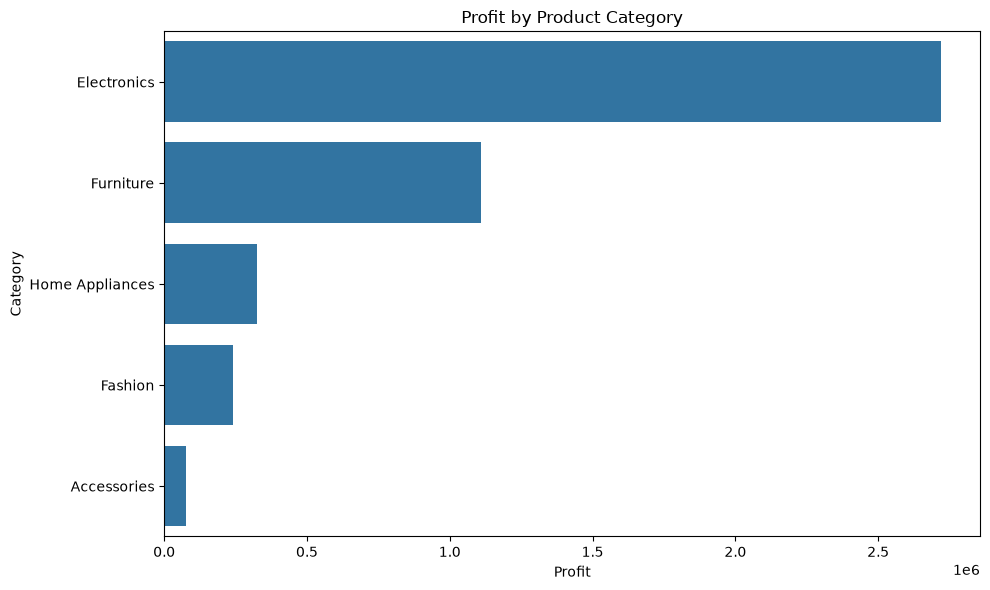

In [482]:
category_profit
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_profit.values,
    y=category_profit.index
)

plt.title("Profit by Product Category")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

In [483]:
# Create a KPI Summary
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Net Sales",
        "Total Orders",
        "Total Customers",
        "Total Units Sold",
        "Average Order Value"
    ],
    "Value": [
        total_sales,
        total_orders,
        total_customers,
        total_units,
        average_order_value
    ]
})

kpi_summary

,Metric,Value
0,Total Net Sales,25075610.00
1,Total Orders,1000.00
2,Total Customers,290.00
3,Total Units Sold,2486.00
4,Average Order Value,25075.61


In [484]:
# Analyze Sales by Category
# Which product category generates the most sales?
## 2. Sales by Category
category_sales = (
    cleaned_df
    .groupby("Category")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Electronics        17190875.0
Furniture           5294075.0
Home Appliances     1368450.0
Fashion              914050.0
Accessories          308160.0
Name: Net_Sales, dtype: float64

In [485]:
# Visualize Category Sales
import matplotlib.pyplot as plt
import seaborn as sns

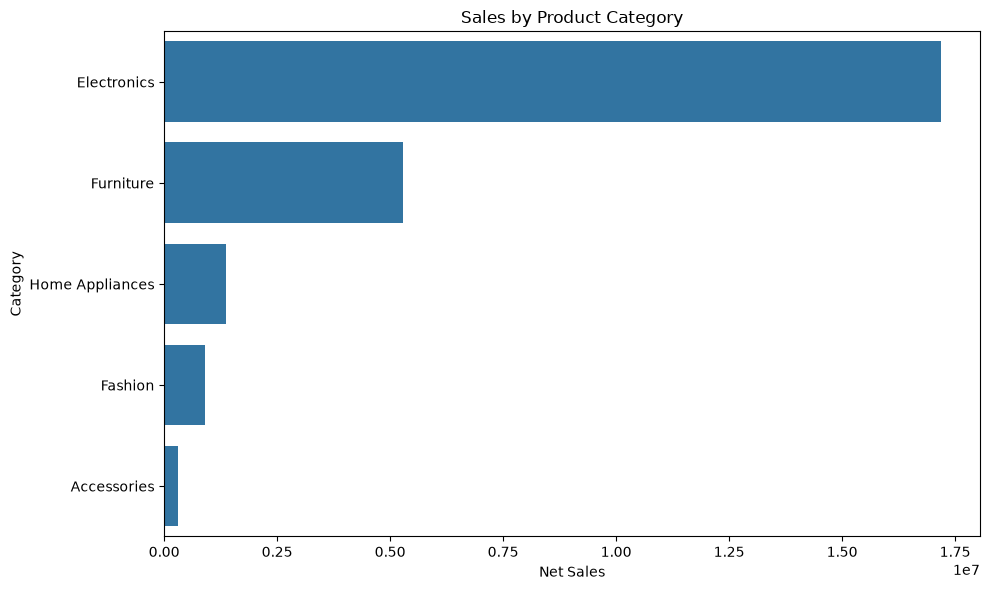

In [486]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Sales by Product Category")
plt.xlabel("Net Sales")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

In [487]:
# Sales by Product
# Which individual products generate the most revenue?
product_sales = (
    cleaned_df
    .groupby("Product")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

Product
Laptop           11632500.0
Smartphone        4178750.0
Desk              2369400.0
Office Chair      1577175.0
Bookshelf         1347500.0
Smartwatch        1034000.0
Coffee Maker       895950.0
Shoes              706825.0
Mixer Grinder      472500.0
Headphones         345625.0
Backpack           308160.0
T-Shirt            207225.0
Name: Net_Sales, dtype: float64

In [488]:
# Top 10 Products
top_10_products = product_sales.head(10)

top_10_products

Product
Laptop           11632500.0
Smartphone        4178750.0
Desk              2369400.0
Office Chair      1577175.0
Bookshelf         1347500.0
Smartwatch        1034000.0
Coffee Maker       895950.0
Shoes              706825.0
Mixer Grinder      472500.0
Headphones         345625.0
Name: Net_Sales, dtype: float64

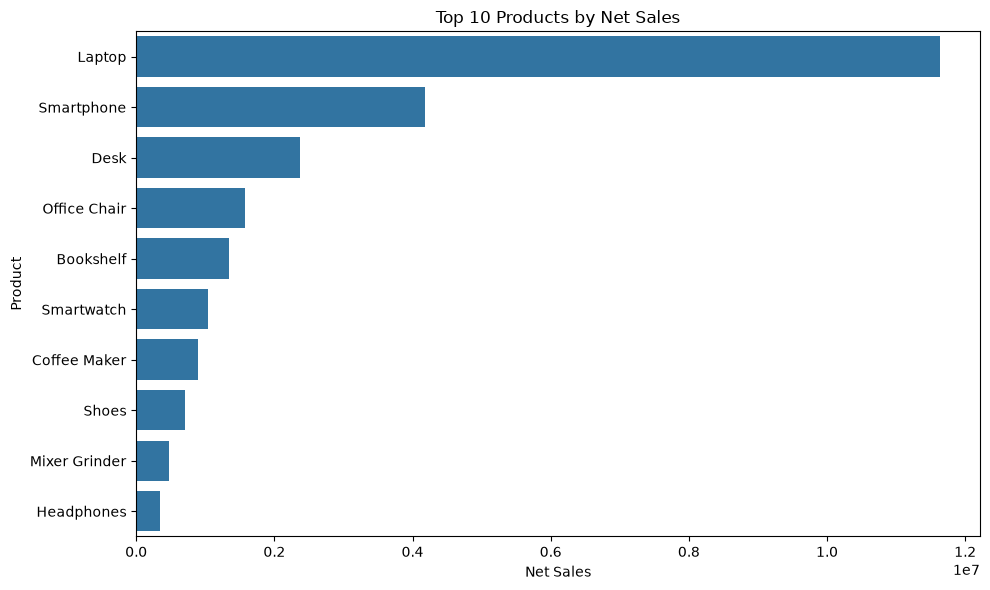

In [489]:
# Visualize Top Products
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title("Top 10 Products by Net Sales")
plt.xlabel("Net Sales")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [490]:
## 3. Monthly Sales Trend
monthly_sales = (
    cleaned_df
    .groupby("Month")["Net_Sales"]
    .sum()
)

monthly_sales

Month
1     2067440.0
2     1922360.0
3     1823645.0
4     2577650.0
5     2305450.0
6     1735655.0
7     2147790.0
8     2430330.0
9     1864210.0
10    2724725.0
11    1721635.0
12    1754720.0
Name: Net_Sales, dtype: float64

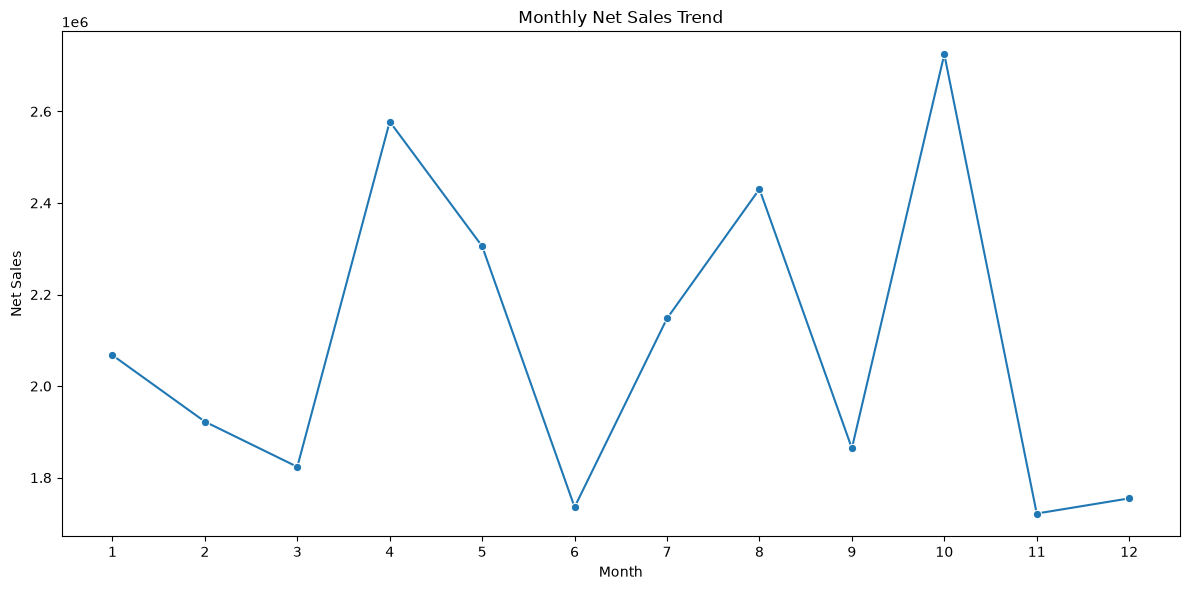

In [491]:
# Create a Monthly Sales Chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Net Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales")
plt.xticks(range(1, 13))
plt.tight_layout()

plt.show()

In [492]:
# Sales by Region
## 4. Regional Sales Performance
regional_sales = (
    cleaned_df
    .groupby("Region")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

regional_sales

Region
West     7345030.0
East     6138430.0
South    5835165.0
North    5756985.0
Name: Net_Sales, dtype: float64

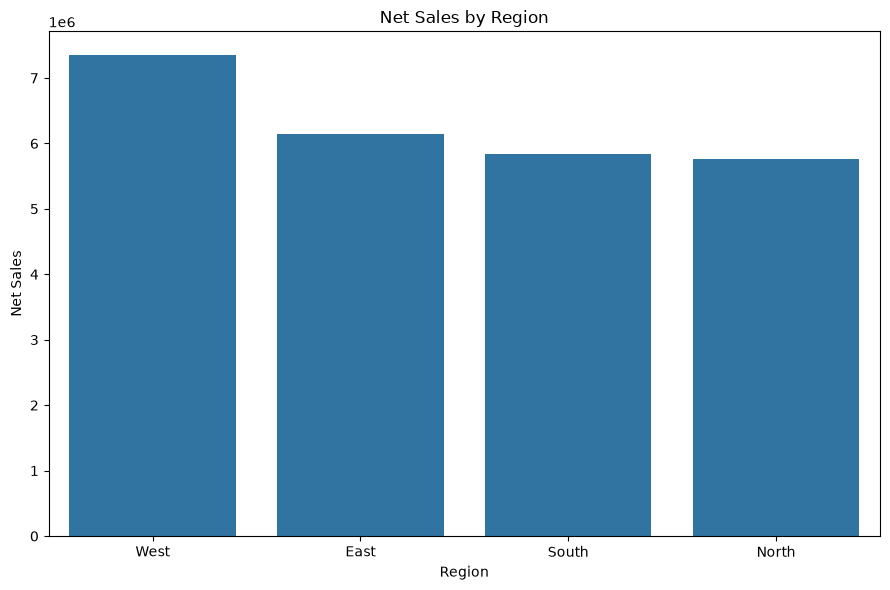

In [493]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=regional_sales.index,
    y=regional_sales.values
)

plt.title("Net Sales by Region")
plt.xlabel("Region")
plt.ylabel("Net Sales")
plt.tight_layout()

plt.show()

In [494]:
# City-Level Analysis
city_sales = (
    cleaned_df
    .groupby("City")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

city_sales.head(10)

City
Pune           3048720.0
Mumbai         2456525.0
Delhi          2326390.0
Bengaluru      2301870.0
Patna          2291830.0
Jaipur         2140375.0
Bhubaneswar    2086020.0
Ahmedabad      1789785.0
Hyderabad      1769110.0
Chennai        1764185.0
Name: Net_Sales, dtype: float64

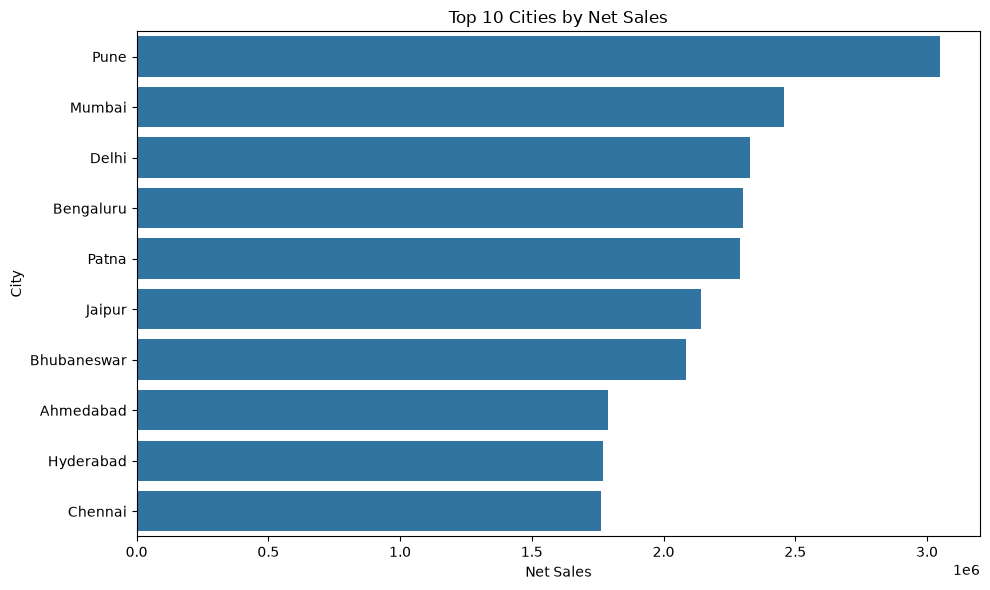

In [495]:
top_cities = city_sales.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Net Sales")
plt.xlabel("Net Sales")
plt.ylabel("City")
plt.tight_layout()

plt.show()

In [496]:
# Payment Method Analysis
## 5. Payment Method Analysis
payment_counts = cleaned_df["Payment_Method"].value_counts()

payment_counts

Payment_Method
Cash on Delivery    218
Debit Card          212
UPI                 197
Credit Card         189
Net Banking         183
Unknown               1
Name: count, dtype: int64

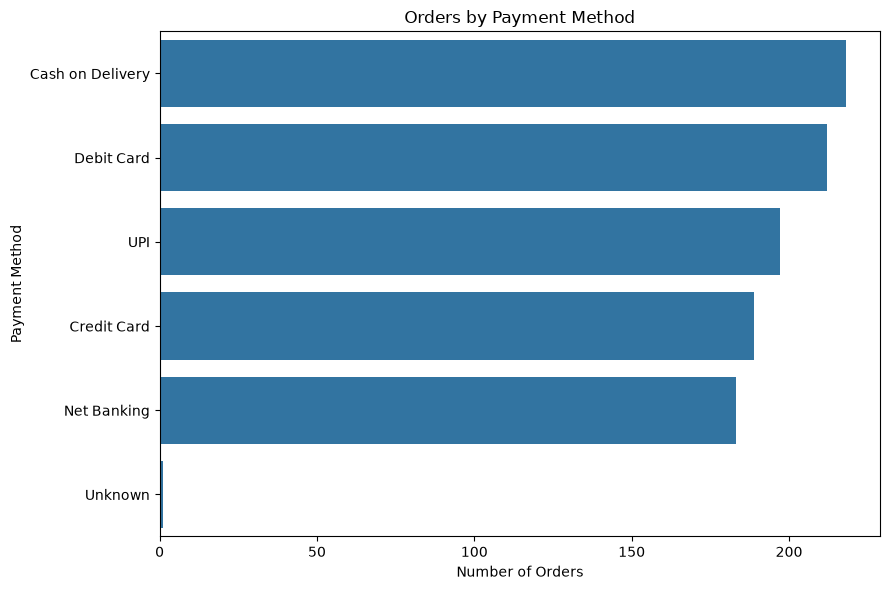

In [497]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=payment_counts.values,
    y=payment_counts.index
)

plt.title("Orders by Payment Method")
plt.xlabel("Number of Orders")
plt.ylabel("Payment Method")
plt.tight_layout()

plt.show()

In [498]:
# Order Status Analysis
status_counts = cleaned_df["Order_Status"].value_counts()

status_counts

Order_Status
Delivered    557
Returned     167
Shipped      141
Cancelled    135
Name: count, dtype: int64

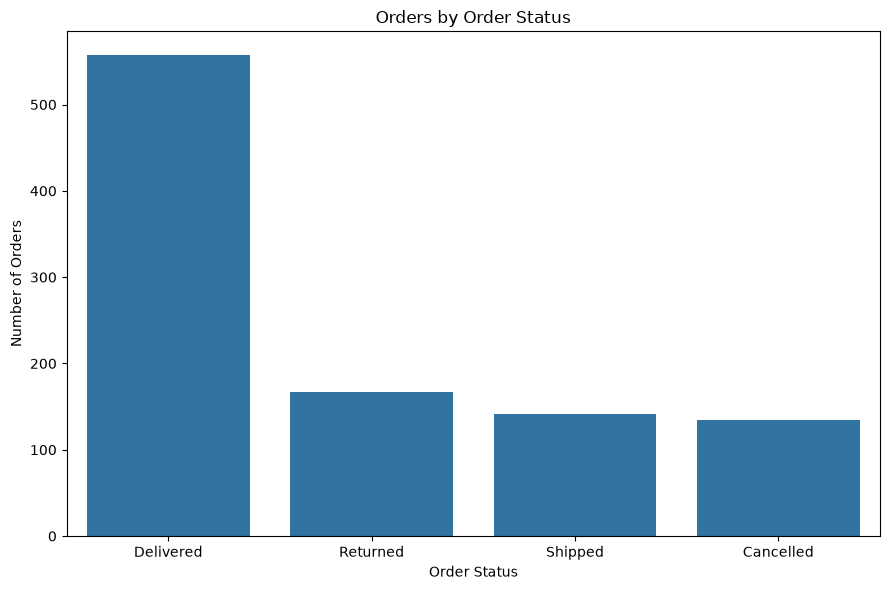

In [499]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

plt.title("Orders by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.show()

# Advanced Exploratory Data Analysis
## 6. Profitability Analysis

In [500]:
# Analyze Net Sales vs Shipping Cost
#Net_Sales
#Shipping_Cost
#Contribution_After_Shipping
total_net_sales = cleaned_df["Net_Sales"].sum()
total_shipping_cost = cleaned_df["Shipping_Cost"].sum()
total_contribution = cleaned_df["Contribution_After_Shipping"].sum()

print(f"Total Net Sales: ₹{total_net_sales:,.2f}")
print(f"Total Shipping Cost: ₹{total_shipping_cost:,.2f}")
print(f"Contribution After Shipping: ₹{total_contribution:,.2f}")

Total Net Sales: ₹25,075,610.00
Total Shipping Cost: ₹277,575.00
Contribution After Shipping: ₹24,798,035.00


In [501]:
# Contribution by Category
category_contribution = (
    cleaned_df
    .groupby("Category")["Contribution_After_Shipping"]
    .sum()
    .sort_values(ascending=False)
)

category_contribution

Category
Electronics        17096881.0
Furniture           5222600.0
Home Appliances     1327844.0
Fashion              861941.0
Accessories          288769.0
Name: Contribution_After_Shipping, dtype: float64

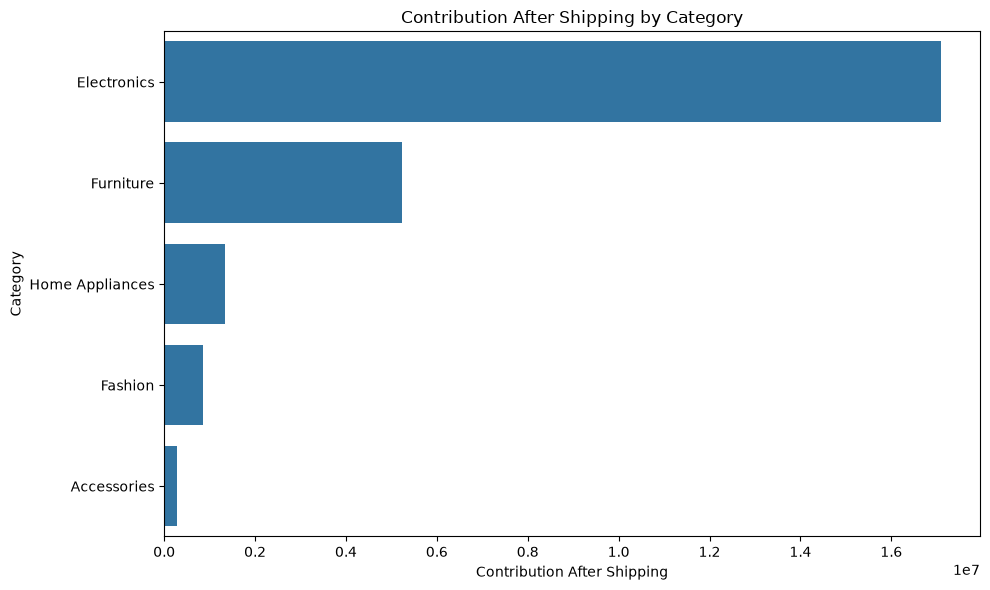

In [502]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_contribution.values,
    y=category_contribution.index
)

plt.title("Contribution After Shipping by Category")
plt.xlabel("Contribution After Shipping")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

In [503]:
# Discount Analysis
## 7. Discount Analysis
total_discount = cleaned_df["Discount_Amount"].sum()

print(f"Total Discount Given: ₹{total_discount:,.2f}")

Total Discount Given: ₹2,731,690.00


In [504]:
average_discount = cleaned_df["Discount"].mean()

print(f"Average Discount Percentage: {average_discount:.2f}%")

Average Discount Percentage: 9.99%


In [505]:
# Discount by Category
discount_by_category = (
    cleaned_df
    .groupby("Category")["Discount"]
    .mean()
    .sort_values(ascending=False)
)

discount_by_category

Category
Accessories        11.866667
Electronics        10.030769
Home Appliances     9.867550
Furniture           9.843137
Fashion             9.510309
Name: Discount, dtype: float64

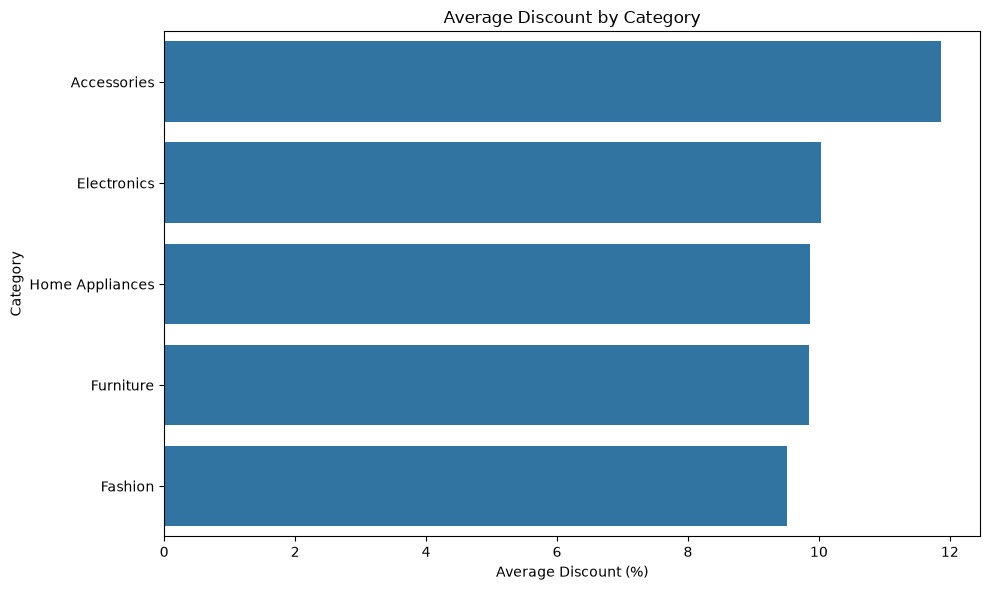

In [506]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=discount_by_category.values,
    y=discount_by_category.index
)

plt.title("Average Discount by Category")
plt.xlabel("Average Discount (%)")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

In [507]:
# Return Rate
total_orders = cleaned_df["Order_ID"].nunique()

returned_orders = (
    cleaned_df["Order_Status"] == "Returned"
).sum()

return_rate = returned_orders / total_orders * 100

print(f"Returned Orders: {returned_orders}")
print(f"Return Rate: {return_rate:.2f}%")

Returned Orders: 167
Return Rate: 16.70%


In [508]:
# Cancellation Rate
cancelled_orders = (
    cleaned_df["Order_Status"] == "Cancelled"
).sum()

cancellation_rate = cancelled_orders / total_orders * 100

print(f"Cancelled Orders: {cancelled_orders}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancelled Orders: 135
Cancellation Rate: 13.50%


In [509]:
# Create an Order Quality KPI Table
order_quality = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Delivered Orders",
        "Returned Orders",
        "Cancelled Orders",
        "Return Rate (%)",
        "Cancellation Rate (%)"
    ],
    "Value": [
        total_orders,
        (cleaned_df["Order_Status"] == "Delivered").sum(),
        returned_orders,
        cancelled_orders,
        return_rate,
        cancellation_rate
    ]
})

order_quality

,Metric,Value
0,Total Orders,1000.0
1,Delivered Orders,557.0
2,Returned Orders,167.0
3,Cancelled Orders,135.0
4,Return Rate (%),16.7
5,Cancellation Rate (%),13.5


In [510]:
# Customer Analysis
customer_sales = (
    cleaned_df
    .groupby("Customer_ID")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

Customer_ID
CUST045    517700.0
CUST068    395325.0
CUST149    354960.0
CUST093    338775.0
CUST183    338500.0
CUST178    319320.0
CUST164    313010.0
CUST294    304840.0
CUST054    302950.0
CUST219    301910.0
Name: Net_Sales, dtype: float64

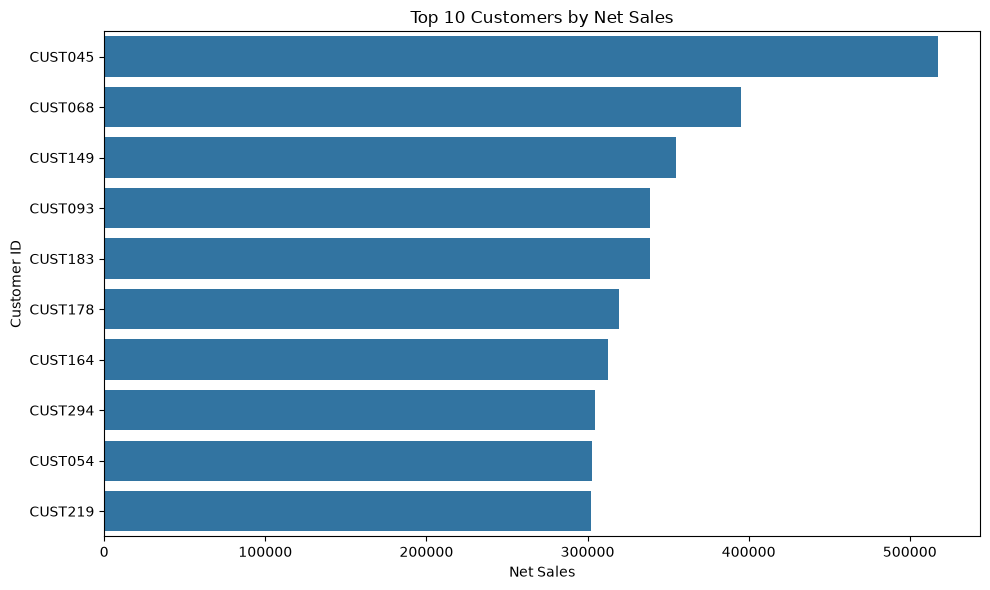

In [511]:
# Top 10 Customers Visualization
top_customers = customer_sales.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top 10 Customers by Net Sales")
plt.xlabel("Net Sales")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.show()

In [512]:
# Orders per Customer
customer_orders = (
    cleaned_df
    .groupby("Customer_ID")["Order_ID"]
    .nunique()
    .sort_values(ascending=False)
)

customer_orders.head(10)

Customer_ID
CUST045    9
CUST129    9
CUST093    8
CUST173    8
CUST192    8
CUST026    7
CUST039    7
CUST267    7
CUST248    7
CUST226    7
Name: Order_ID, dtype: int64

In [513]:
# Average Customer Order Value
customer_aov = (
    cleaned_df
    .groupby("Customer_ID")["Net_Sales"]
    .sum()
    /
    cleaned_df
    .groupby("Customer_ID")["Order_ID"]
    .nunique()
)

customer_aov.sort_values(ascending=False).head(10)

Customer_ID
CUST092    119000.000000
CUST183    112833.333333
CUST174    110855.000000
CUST206    108250.000000
CUST081     89716.666667
CUST274     88000.000000
CUST196     86925.000000
CUST197     85533.333333
CUST187     82625.000000
CUST211     81125.000000
dtype: float64

In [514]:
# Category Quantity Analysis
## 9. Quantity vs Revenue Analysis
category_quantity = (
    cleaned_df
    .groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

category_quantity

Category
Electronics        805
Furniture          638
Fashion            479
Home Appliances    370
Accessories        194
Name: Quantity, dtype: int64

In [515]:
category_sales

Category
Electronics        17190875.0
Furniture           5294075.0
Home Appliances     1368450.0
Fashion              914050.0
Accessories          308160.0
Name: Net_Sales, dtype: float64

In [516]:
# Product Quantity Analysis
product_quantity = (
    cleaned_df
    .groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

Product
T-Shirt         254
Laptop          235
Smartwatch      231
Shoes           225
Coffee Maker    218
Desk            217
Bookshelf       214
Office Chair    207
Backpack        194
Smartphone      184
Name: Quantity, dtype: int64

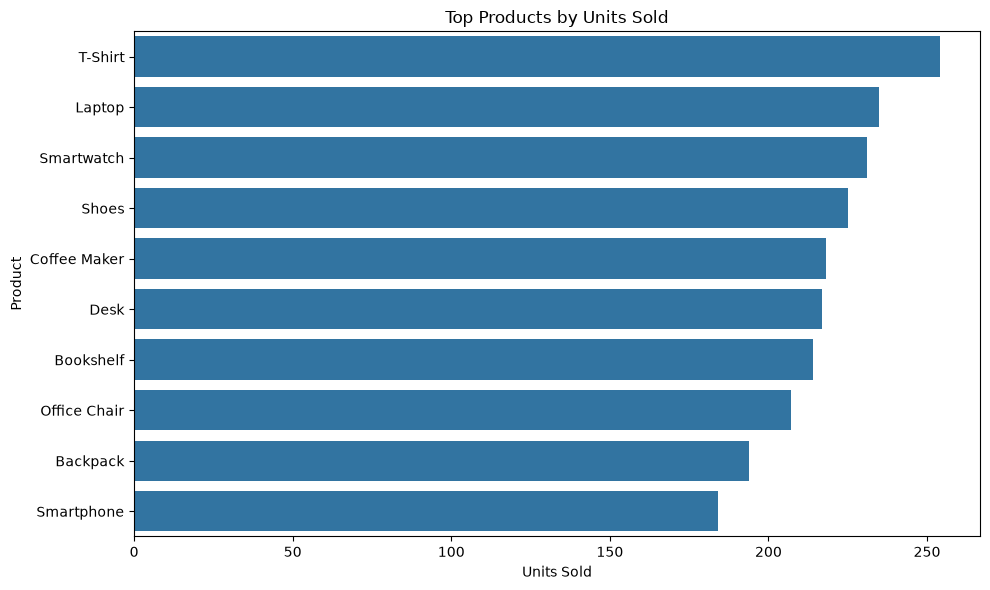

In [517]:
top_quantity_products = product_quantity.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_quantity_products.values,
    y=top_quantity_products.index
)

plt.title("Top Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [518]:
# Monthly Orders
monthly_orders = (
    cleaned_df
    .groupby("Month")["Order_ID"]
    .nunique()
)

monthly_orders

Month
1     92
2     67
3     89
4     83
5     84
6     71
7     97
8     99
9     66
10    83
11    84
12    85
Name: Order_ID, dtype: int64

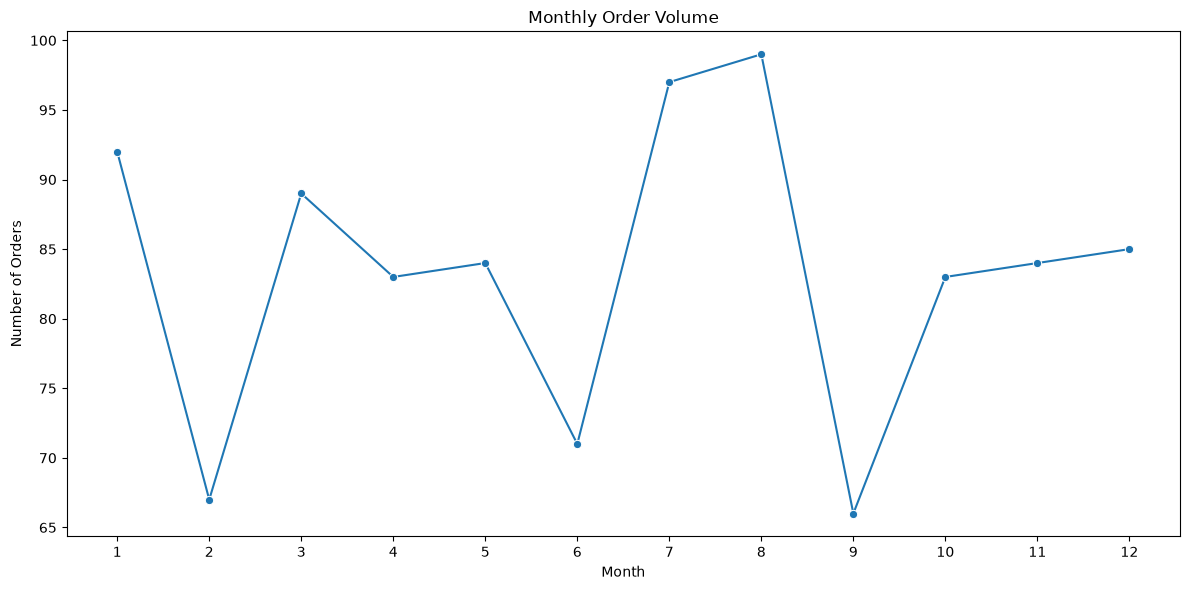

In [519]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_orders.index,
    y=monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(range(1, 13))
plt.tight_layout()

plt.show()

In [520]:
# Monthly Average Order Value
monthly_aov = (
    cleaned_df
    .groupby("Month")
    .agg(
        Revenue=("Net_Sales", "sum"),
        Orders=("Order_ID", "nunique")
    )
)

monthly_aov["AOV"] = (
    monthly_aov["Revenue"] /
    monthly_aov["Orders"]
)

monthly_aov

,Revenue,Orders,AOV
Month,,,
1,2067440.0,92,22472.173913
2,1922360.0,67,28691.940299
3,1823645.0,89,20490.393258
4,2577650.0,83,31056.024096
5,2305450.0,84,27445.833333
6,1735655.0,71,24445.845070
7,2147790.0,97,22142.164948
8,2430330.0,99,24548.787879
9,1864210.0,66,28245.606061


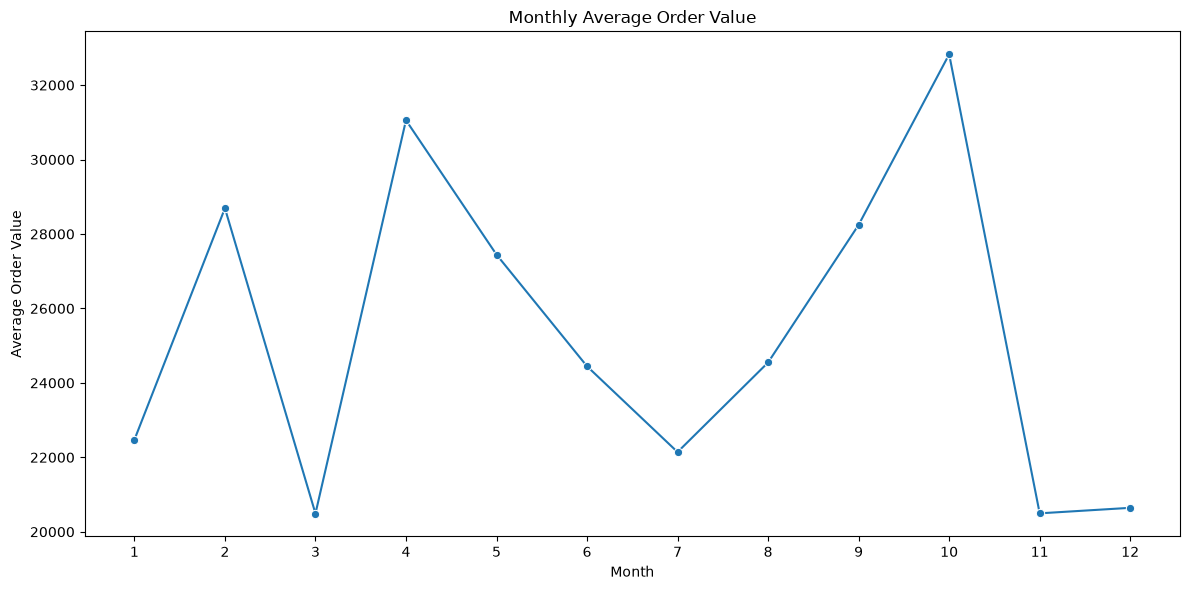

In [521]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_aov.index,
    y=monthly_aov["AOV"],
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(range(1, 13))
plt.tight_layout()

plt.show()

In [522]:
# Correlation Analysis
numeric_columns = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Shipping_Cost",
    "Gross_Sales",
    "Discount_Amount",
    "Net_Sales",
    "Contribution_After_Shipping"
]

correlation_matrix = cleaned_df[numeric_columns].corr()

correlation_matrix

,Quantity,Unit_Price,Discount,Shipping_Cost,Gross_Sales,Discount_Amount,Net_Sales,Contribution_After_Shipping
Quantity,1.000000,0.024778,0.010722,-0.071735,0.305112,0.238230,0.303796,0.304084
Unit_Price,0.024778,1.000000,-0.025016,0.108409,0.879778,0.688852,0.875715,0.875495
Discount,0.010722,-0.025016,1.000000,-0.038265,-0.015308,0.327018,-0.062527,-0.062410
Shipping_Cost,-0.071735,0.108409,-0.038265,1.000000,0.053892,0.069774,0.049796,0.046472
Gross_Sales,0.305112,0.879778,-0.015308,0.053892,1.000000,0.777518,0.996145,0.996125
Discount_Amount,0.238230,0.688852,0.327018,0.069774,0.777518,1.000000,0.719355,0.719238
Net_Sales,0.303796,0.875715,-0.062527,0.049796,0.996145,0.719355,1.000000,0.999994
Contribution_After_Shipping,0.304084,0.875495,-0.062410,0.046472,0.996125,0.719238,0.999994,1.000000


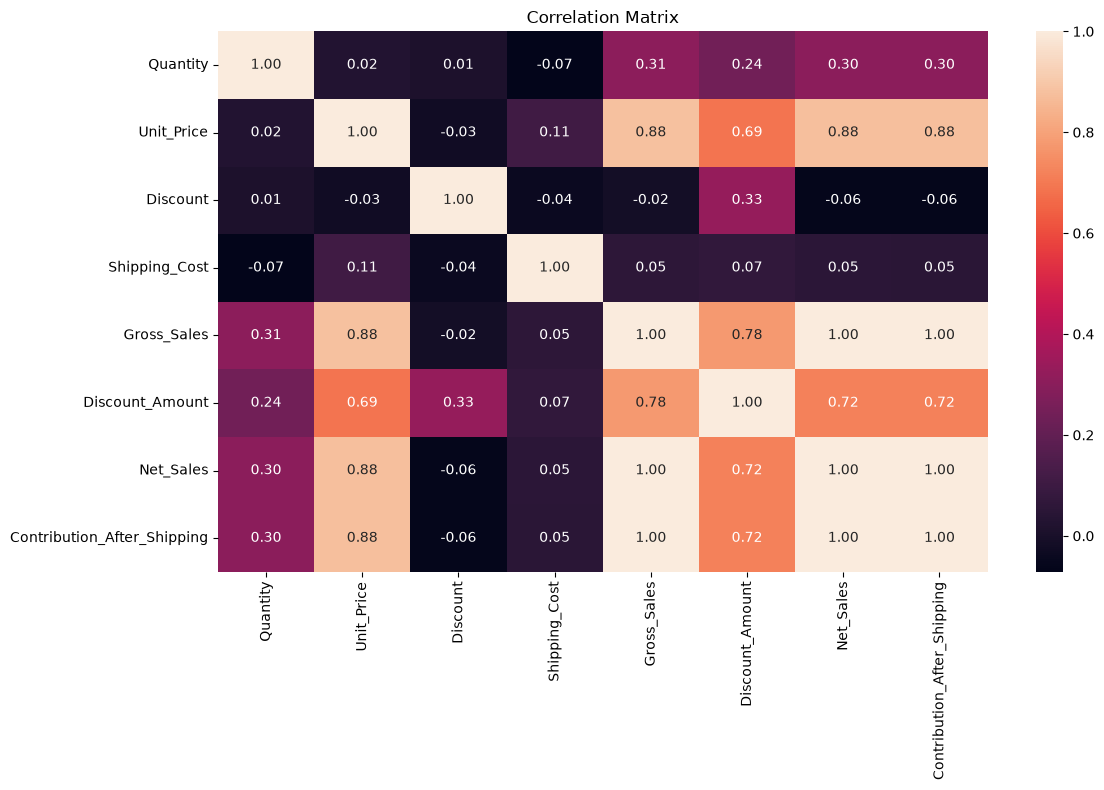

In [523]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

In [524]:
# Build a Business Summary Table
business_summary = pd.DataFrame({
    "Metric": [
        "Total Net Sales",
        "Total Orders",
        "Total Customers",
        "Total Units Sold",
        "Average Order Value",
        "Total Discount Given",
        "Total Shipping Cost",
        "Contribution After Shipping",
        "Return Rate (%)",
        "Cancellation Rate (%)"
    ],
    "Value": [
        total_net_sales,
        total_orders,
        total_customers,
        total_units,
        average_order_value,
        total_discount,
        total_shipping_cost,
        total_contribution,
        return_rate,
        cancellation_rate
    ]
})

business_summary

,Metric,Value
0,Total Net Sales,25075610.00
1,Total Orders,1000.00
2,Total Customers,290.00
3,Total Units Sold,2486.00
4,Average Order Value,25075.61
5,Total Discount Given,2731690.00
6,Total Shipping Cost,277575.00
7,Contribution After Shipping,24798035.00
8,Return Rate (%),16.70
9,Cancellation Rate (%),13.50


In [525]:
# Identify the Top Performers Automatically
top_category = category_sales.idxmax()
top_category_sales = category_sales.max()

top_product = product_sales.idxmax()
top_product_sales = product_sales.max()

top_region = regional_sales.idxmax()
top_region_sales = regional_sales.max()

top_city = city_sales.idxmax()
top_city_sales = city_sales.max()

print(f"Top Category: {top_category}")
print(f"Top Category Sales: ₹{top_category_sales:,.2f}")

print(f"\nTop Product: {top_product}")
print(f"Top Product Sales: ₹{top_product_sales:,.2f}")

print(f"\nTop Region: {top_region}")
print(f"Top Region Sales: ₹{top_region_sales:,.2f}")

print(f"\nTop City: {top_city}")
print(f"Top City Sales: ₹{top_city_sales:,.2f}")

Top Category: Electronics
Top Category Sales: ₹17,190,875.00

Top Product: Laptop
Top Product Sales: ₹11,632,500.00

Top Region: West
Top Region Sales: ₹7,345,030.00

Top City: Pune
Top City Sales: ₹3,048,720.00


# Business Insights

## Key Findings

### 1. Category Performance
Electronics is the highest-performing category with net sales of approximately ₹17.19 million. It is the primary revenue contributor in the dataset.

### 2. Product Performance
Laptop is the highest-selling product by net sales, generating approximately ₹11.63 million.

### 3. Regional Performance
The West region is the strongest-performing region, generating approximately ₹7.35 million in net sales.

### 4. City Performance
Pune is the highest-performing city, generating approximately ₹3.05 million in net sales.

### 5. Return Performance
The return rate is 16.70%, which indicates that a meaningful proportion of orders are being returned and warrants further investigation.

### 6. Cancellation Performance
The cancellation rate is 13.50%, suggesting that order cancellations are also a significant operational metric.

### 7. Contribution After Shipping
The contribution after shipping is approximately ₹24.80 million. This should not be interpreted as final profit because product acquisition/manufacturing costs have not been included.

In [526]:
# Save the Final Dataset
cleaned_df.to_csv(
    "../data/processed/cleaned_ecommerce_sales.csv",
    index=False
)

In [527]:
cleaned_df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Customer_ID',
 'Product',
 'Category',
 'Quantity',
 'Unit_Price',
 'Product_Cost',
 'Discount',
 'Payment_Method',
 'Region',
 'City',
 'Order_Status',
 'Shipping_Cost',
 'Gross_Sales',
 'Discount_Amount',
 'Net_Sales',
 'Total_Product_Cost',
 'Profit',
 'Profit_Margin',
 'Contribution_After_Shipping',
 'Year',
 'Month',
 'Month_Name',
 'Quarter']

In [528]:
cleaned_df.shape

(1000, 25)